# NISAR L2 GCOV — Single-Scene Wetland Inundation Classification

Adapted from the NISAR ATBD notebook (Chapman & Siqueira, 2022; updated Christensen/Downs 2025).

**Changes from original:**
- Loads a single local `.nc` file instead of S3/earthaccess time series
- Thresholds defined directly in code (no YAML)
- Removed multi-temporal stack logic (single scene)
- Uses `rasterio` for 1-ha aggregation (replaces `gdal.Warp`)
- Polarization set to `DHDH`/`DVDV` — **confirm channel names via the inspection cell before running Step 2**

## Step 0: Configuration — Edit This Cell

In [1]:
from pathlib import Path

# --- PATH TO YOUR FILE ---
nc_path = Path('data/nisar_s1_figure/NISAR/NISAR_L2_PR_GCOV_007_172_D_064_4005_DHDH_A_20251216T031815_20251216T031850_X05009_N_F_J_001.nc')

# --- AOI label used for output filenames ---
aoi = 'WA_flood'

# --- Co-pol and cross-pol channel names (confirm via inspection cell below) ---
copol_name   = 'HHHH'   # e.g. HHHH, DHDH
crosspol_name = 'HVHV'  # e.g. HVHV, DVDV

# --- Combination method for open water: 'sum' or 'product' ---
comb_method = 'sum'

# --- Output directory for GeoTIFFs ---
output_dir = Path('nisar_classifications') / aoi

## Step 1: Imports and Load Data

In [2]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import warnings
from matplotlib.colors import LinearSegmentedColormap
from datetime import datetime
import rasterio
from rasterio.enums import Resampling
import rioxarray as rxr
import pandas as pd

In [3]:
# Parse date from filename
# Filename field 11 (0-indexed) is the start datetime: 20251216T031815
fname_parts = nc_path.stem.split('_')
datestr = fname_parts[11]          # e.g. '20251216T031815'
gcov_date = f'{datestr[:4]}-{datestr[4:6]}-{datestr[6:8]}'
print('Scene date:', gcov_date)

# Wrap in lists so downstream code stays consistent with original loop structure
gcov_dates = [gcov_date]
num_files = 1

Scene date: 2025-12-16


### 1.1 Inspect the HDF5 structure
Run this cell **before** reading data. Confirm the correct paths for your polarization bands,
x/y coordinates, and projection. Update `copol_name`, `crosspol_name`, and the HDF5 group
paths in Step 1.2 if they differ from the defaults.

In [4]:
with h5py.File(nc_path, 'r') as f:
    def print_all_objs(name, obj):
        print(obj)
    f.visititems(print_all_objs)

<HDF5 group "/science" (1 members)>
<HDF5 group "/science/LSAR" (2 members)>
<HDF5 group "/science/LSAR/GCOV" (2 members)>
<HDF5 group "/science/LSAR/GCOV/grids" (2 members)>
<HDF5 group "/science/LSAR/GCOV/grids/frequencyA" (13 members)>
<HDF5 dataset "HHHH": shape (35784, 36144), type "<f4">
<HDF5 dataset "HVHV": shape (35784, 36144), type "<f4">
<HDF5 dataset "listOfCovarianceTerms": shape (2,), type "|S4">
<HDF5 dataset "listOfPolarizations": shape (2,), type "|S2">
<HDF5 dataset "mask": shape (35784, 36144), type "|u1">
<HDF5 dataset "numberOfLooks": shape (35784, 36144), type "<f4">
<HDF5 dataset "numberOfSubSwaths": shape (), type "|u1">
<HDF5 dataset "projection": shape (), type "<u4">
<HDF5 dataset "rtcGammaToSigmaFactor": shape (35784, 36144), type "<f4">
<HDF5 dataset "xCoordinateSpacing": shape (), type "<f8">
<HDF5 dataset "xCoordinates": shape (36144,), type "<f8">
<HDF5 dataset "yCoordinateSpacing": shape (), type "<f8">
<HDF5 dataset "yCoordinates": shape (35784,), type

### 1.2 Read coordinates and backscatter

In [5]:
# NOTE: if visititems shows a different top-level group (e.g. 'DSAR' instead of 'LSAR'),
#       or frequencyB instead of frequencyA, update the paths below accordingly.
GRID_PATH = 'science/LSAR/GCOV/grids/frequencyA'

with h5py.File(nc_path, 'r') as f:
    grid = f[GRID_PATH]
    ds_x    = grid['xCoordinates'][()]
    ds_y    = grid['yCoordinates'][()]
    ds_epsg = grid['projection'][()].item()
    ds_copol   = grid[copol_name][()]
    ds_crosspol = grid[crosspol_name][()]

# Wrap in lists to match original notebook's list-of-scenes convention
ds_HHHH = [ds_copol]
ds_HVHV = [ds_crosspol]

print(f'EPSG: {ds_epsg}')
print(f'x shape: {ds_x.shape},  y shape: {ds_y.shape}')
print(f'{copol_name} shape: {ds_copol.shape},  dtype: {ds_copol.dtype}')
print(f'{crosspol_name} shape: {ds_crosspol.shape},  dtype: {ds_crosspol.dtype}')

EPSG: 32610
x shape: (36144,),  y shape: (35784,)
HHHH shape: (35784, 36144),  dtype: float32
HVHV shape: (35784, 36144),  dtype: float32


In [6]:
import geopandas as gpd
from shapely.geometry import box

# Load shapefile
shapefile_path = "data/nisar_s1_figure/shapefiles/skagit_river_flood.shp"
shp = gpd.read_file(shapefile_path)
clip_bounds = shp.total_bounds  # [minx, miny, maxx, maxy]

# Reproject bounds to match raster CRS if needed
if shp.crs != f'EPSG:{ds_epsg}':
    shp_reproj = shp.to_crs(f'EPSG:{ds_epsg}')
    clip_bounds = shp_reproj.total_bounds

# Find pixel indices within the bounding box (much faster than point-in-polygon)
minx, miny, maxx, maxy = clip_bounds
col_indices = np.where((ds_x >= minx) & (ds_x <= maxx))[0]
row_indices = np.where((ds_y >= miny) & (ds_y <= maxy))[0]

if len(col_indices) > 0 and len(row_indices) > 0:
    col_min, col_max = col_indices[0], col_indices[-1] + 1
    row_min, row_max = row_indices[0], row_indices[-1] + 1
    print(f'Clipping to rows {row_min}:{row_max}, cols {col_min}:{col_max}')
else:
    raise ValueError('No pixels found within shapefile bounds!')

# Read only the clipped region from the HDF5 file
GRID_PATH = 'science/LSAR/GCOV/grids/frequencyA'
with h5py.File(nc_path, 'r') as f:
    grid = f[GRID_PATH]
    ds_x_clipped = grid['xCoordinates'][col_min:col_max]
    ds_y_clipped = grid['yCoordinates'][row_min:row_max]
    ds_copol_clipped = grid[copol_name][row_min:row_max, col_min:col_max]
    ds_crosspol_clipped = grid[crosspol_name][row_min:row_max, col_min:col_max]

print(f'Clipped data shape: {ds_copol_clipped.shape}')

Clipping to rows 14403:18981, cols 12752:18465
Clipped data shape: (4578, 5713)


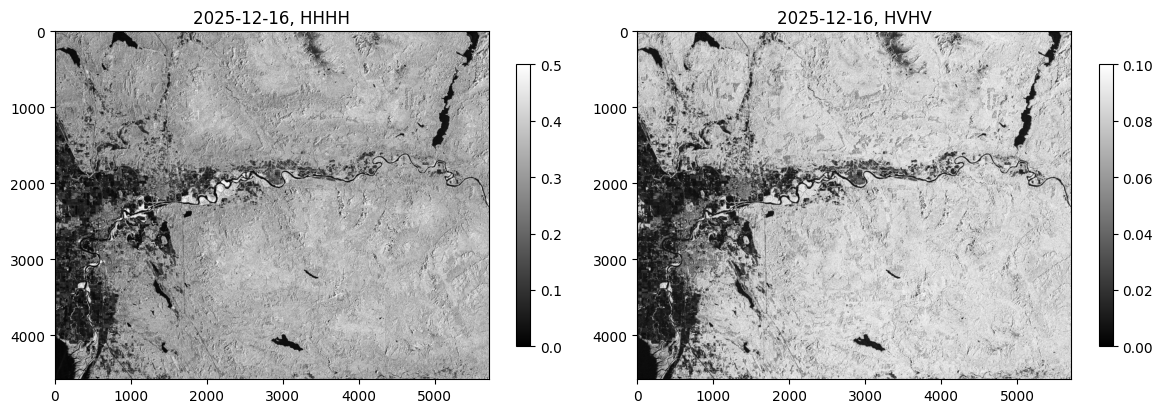

In [7]:
# Plot the raw backscatter
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
cbar_shrink = 0.6

im1 = axs[0].imshow(ds_copol_clipped, vmin=0, vmax=0.5, cmap='gray')
axs[0].set_title(f'{gcov_dates[0]}, {copol_name}')
fig.colorbar(im1, ax=axs[0], shrink=cbar_shrink)

im2 = axs[1].imshow(ds_crosspol_clipped, vmin=0, vmax=0.1, cmap='gray')
axs[1].set_title(f'{gcov_dates[0]}, {crosspol_name}')
fig.colorbar(im2, ax=axs[1], shrink=cbar_shrink)

plt.tight_layout()
plt.show()

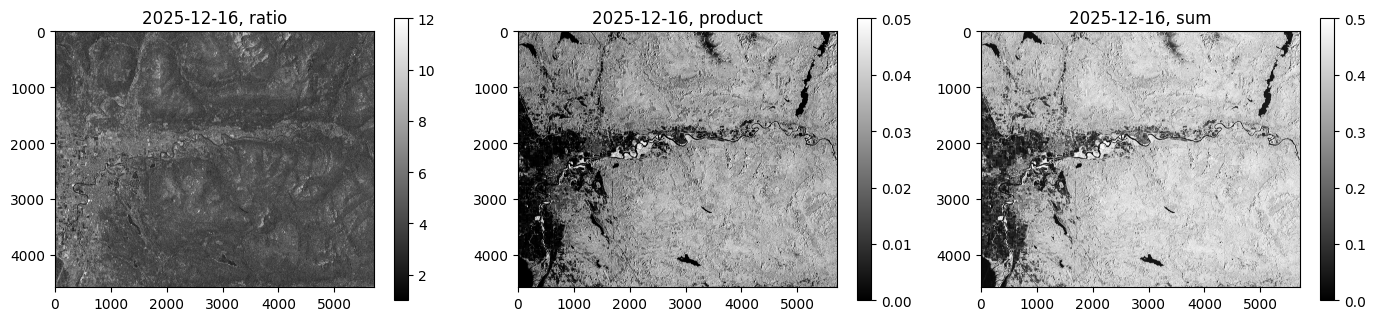

In [8]:
# Compute derived bands
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    ds_ratio   = [ds_copol_clipped / ds_crosspol_clipped]
    ds_product = [ds_copol_clipped * ds_crosspol_clipped]
    ds_sum     = [ds_copol_clipped + ds_crosspol_clipped]

# Plot ratio, product, sum
fig, axs = plt.subplots(1, 3, figsize=(14, 5))
cbar_shrink = 0.6

im1 = axs[0].imshow(ds_ratio[0],   vmin=1,  vmax=12,   cmap='gray')
axs[0].set_title(f'{gcov_dates[0]}, ratio')
fig.colorbar(im1, ax=axs[0], shrink=cbar_shrink)

im2 = axs[1].imshow(ds_product[0], vmin=0,  vmax=0.05, cmap='gray')
axs[1].set_title(f'{gcov_dates[0]}, product')
fig.colorbar(im2, ax=axs[1], shrink=cbar_shrink)

im3 = axs[2].imshow(ds_sum[0],     vmin=0,  vmax=0.5,  cmap='gray')
axs[2].set_title(f'{gcov_dates[0]}, sum')
fig.colorbar(im3, ax=axs[2], shrink=cbar_shrink)

plt.tight_layout()
plt.show()

## Step 2: Define Classification Thresholds

Set these based on your scene's backscatter distributions. Use the histograms below to guide you.

| Class | Logic |
|---|---|
| Open water (2) | `comb_method` (sum or product) within `[ow_comb_min, ow_comb_max]` |
| Inundated veg (3) | co-pol within `[iv_hh_min, iv_hh_max]` AND ratio within `[iv_ratio_min, iv_ratio_max]` AND not open water |
| Not inundated (1) | all other valid pixels |
| No data (0) | combined value ≤ 0 |

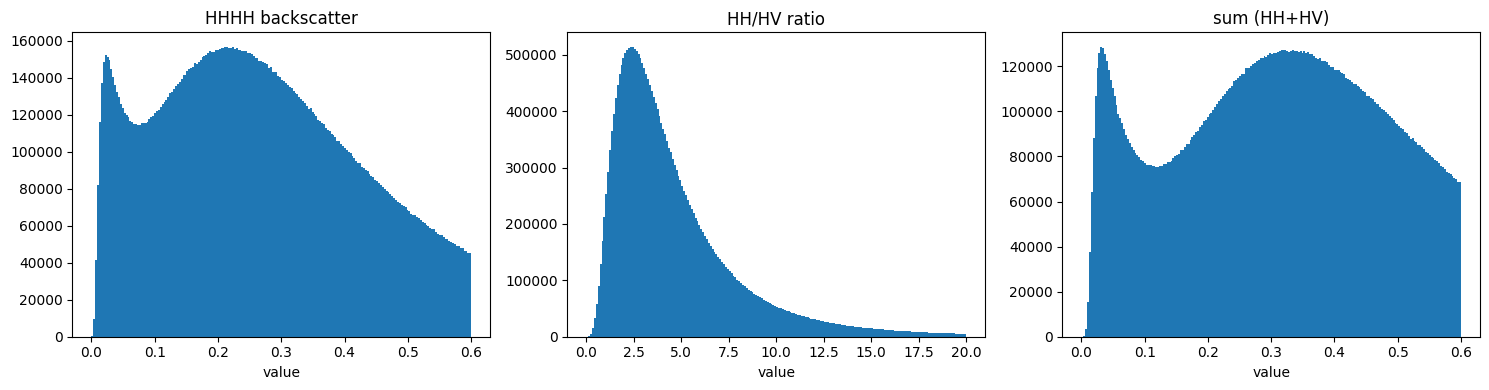

In [9]:
# Backscatter histograms to help set thresholds
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

valid = ds_copol_clipped[ds_copol_clipped > 0]
axs[0].hist(valid.ravel(), bins=200, range=(0, 0.6))
axs[0].set_title(f'{copol_name} backscatter')
axs[0].set_xlabel('value')

valid_r = ds_ratio[0][np.isfinite(ds_ratio[0]) & (ds_ratio[0] > 0)]
axs[1].hist(valid_r.ravel(), bins=200, range=(0, 20))
axs[1].set_title('HH/HV ratio')
axs[1].set_xlabel('value')

valid_s = ds_sum[0][ds_sum[0] > 0]
axs[2].hist(valid_s.ravel(), bins=200, range=(0, 0.6))
axs[2].set_title('sum (HH+HV)')
axs[2].set_xlabel('value')

plt.tight_layout()
plt.show()

In [10]:
# -----------------------------------------------------------------------
# EDIT THESE thresholds based on the histograms above.
# -----------------------------------------------------------------------
th = {}

# Inundated vegetation thresholds (co-pol and ratio)
th['iv_hh_min']    = 0.07    # minimum HH: at valley between water and veg
th['iv_hh_max']    = 0.3    # maximum HH: at vegetation peak
th['iv_ratio_min'] = 2.5     # minimum ratio: just below the peak (2.5)
th['iv_ratio_max'] = 10.0     # maximum ratio: upper bound to exclude dry vegetation

# Open water thresholds (sum or product depending on comb_method above)
if comb_method == 'sum':
    th['ow_comb_min'] = 0.01
    th['ow_comb_max'] = 0.10   # at the valley between water peak (0) and veg peak (0.35)
elif comb_method == 'product':
    th['ow_comb_min'] = 0.0
    th['ow_comb_max'] = 0.001
else:
    raise ValueError("comb_method must be 'sum' or 'product'")

print('Thresholds:', th)

Thresholds: {'iv_hh_min': 0.07, 'iv_hh_max': 0.3, 'iv_ratio_min': 2.5, 'iv_ratio_max': 10.0, 'ow_comb_min': 0.01, 'ow_comb_max': 0.1}


## Step 3: Classify

In [11]:
np.seterr(invalid='ignore')
nisar_classified_20m = []

# Use clipped data directly (since num_files = 1)
temp = np.zeros(ds_copol_clipped.shape, dtype=np.int8)

ds_comb = ds_sum[0].copy() if comb_method == 'sum' else ds_product[0].copy()

# Class 1: valid data
idx = ds_comb > 0
temp[idx] = 1
numpx = np.sum(temp.ravel())

# Class 2: open water
idx = (ds_comb > th['ow_comb_min']) & (ds_comb <= th['ow_comb_max'])
temp[idx] = 2

# Class 3: inundated vegetation (not already open water)
idx = (ds_copol_clipped >= th['iv_hh_min'])    & (ds_copol_clipped <= th['iv_hh_max']) & \
      (ds_ratio[0] >= th['iv_ratio_min']) & (ds_ratio[0] <= th['iv_ratio_max']) & \
      (temp != 2)
temp[idx] = 3

nisar_classified_20m.append(temp)

print(f'{gcov_dates[0]}')
print(f'  Open water:       {100*np.sum(temp==2)/numpx:.1f}%')
print(f'  Inundated veg:    {100*np.sum(temp==3)/numpx:.1f}%')
print(f'  Not inundated:    {100*np.sum(temp==1)/numpx:.1f}%')

2025-12-16
  Open water:       10.9%
  Inundated veg:    21.4%
  Not inundated:    67.8%


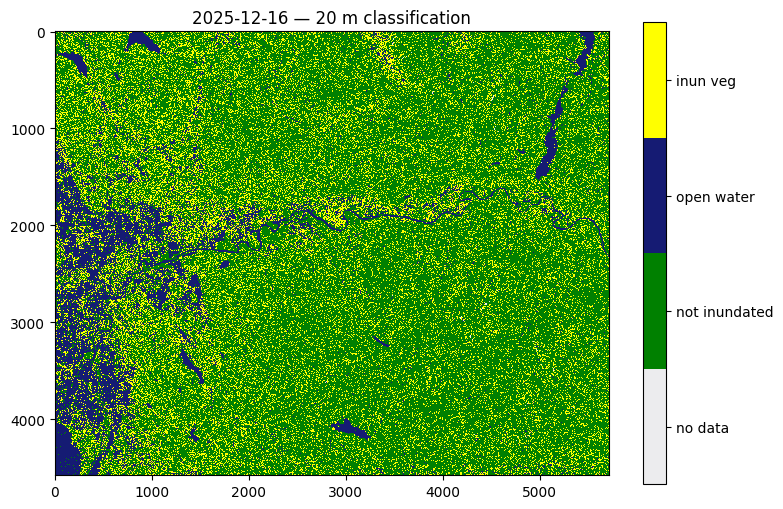

In [12]:
# Plot 20m classification
c_white     = (255, 255, 255)
c_lightblue = (66,  233, 245)
c_darkblue  = (21,  27,  115)
c_gray      = (236, 236, 238)
c_green     = (0, 128, 0)
c_yellow    = (255, 255, 0)

colors2 = [tuple(np.array(c)/255) for c in [c_gray, c_green, c_darkblue, c_yellow]]
cmap = LinearSegmentedColormap.from_list('cmap_class', colors2, N=4)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(nisar_classified_20m[0], vmin=0, vmax=3, cmap=cmap, interpolation='nearest')
ax.set_title(f'{gcov_dates[0]} — 20 m classification')
cbar = fig.colorbar(im, ax=ax, shrink=0.6)
cbar.set_ticks([3/8, 9/8, 15/8, 21/8])
cbar.set_ticklabels(['no data', 'not inundated', 'open water', 'inun veg'], fontsize=10)
plt.tight_layout()
plt.show()

## Step 4: Aggregate to 1 Hectare and Save GeoTIFFs

Uses `rasterio` for both the 20 m write and the 100 m resampling (mode), replacing the original `gdal.Warp`.

In [13]:
output_dir.mkdir(parents=True, exist_ok=True)

# Pixel size (metres) — derived from coordinate arrays
pixel_x = float(ds_x_clipped[1] - ds_x_clipped[0])
pixel_y = float(ds_y_clipped[1] - ds_y_clipped[0])  # negative for north-up rasters

transform_20m = rasterio.transform.from_origin(
    west  = float(ds_x_clipped[0]) - pixel_x / 2,
    north = float(ds_y_clipped[0]) - pixel_y / 2,
    xsize = abs(pixel_x),
    ysize = abs(pixel_y)
)

classification_20m_filenames = []
classification_1ha_filenames = []

for k in range(num_files):
    date_tag = ''.join(gcov_dates[k].split('-'))
    today_tag = datetime.today().strftime('%Y%m%d')

    # --- Write 20 m GeoTIFF ---
    fname_20m = str(output_dir / f'nisar_classified_20m_{today_tag}_gcov_{date_tag}_{aoi}.tif')
    classification_20m_filenames.append(fname_20m)

    meta_20m = {
        'driver': 'GTiff',
        'dtype': 'int8',
        'nodata': 0,
        'width':  nisar_classified_20m[k].shape[1],
        'height': nisar_classified_20m[k].shape[0],
        'count': 1,
        'crs': rasterio.CRS.from_epsg(ds_epsg),
        'transform': transform_20m
    }
    with rasterio.open(fname_20m, 'w', **meta_20m) as dst:
        dst.write(nisar_classified_20m[k], 1)

    # --- Resample to 1 ha (100 m) using mode ---
    fname_1ha = str(output_dir / f'nisar_classified_1ha_{today_tag}_gcov_{date_tag}_{aoi}.tif')
    classification_1ha_filenames.append(fname_1ha)

    scale = int(round(100 / abs(pixel_x)))  # e.g. 100m / 20m = 5

    with rasterio.open(fname_20m) as src:
        new_height = src.height // scale
        new_width  = src.width  // scale
        data_1ha   = src.read(
            out_shape=(1, new_height, new_width),
            resampling=Resampling.mode
        )
        transform_1ha = src.transform * src.transform.scale(
            src.width  / new_width,
            src.height / new_height
        )
        meta_1ha = src.meta.copy()
        meta_1ha.update({'height': new_height, 'width': new_width, 'transform': transform_1ha})

    with rasterio.open(fname_1ha, 'w', **meta_1ha) as dst:
        dst.write(data_1ha)

    print(f'Written: {fname_20m}')
    print(f'Written: {fname_1ha}')

Written: nisar_classifications/WA_flood/nisar_classified_20m_20260417_gcov_20251216_WA_flood.tif
Written: nisar_classifications/WA_flood/nisar_classified_1ha_20260417_gcov_20251216_WA_flood.tif


In [ ]:
# Read and plot 1-ha classification
nisar_classified_1ha = []

ds_1ha = rxr.open_rasterio(classification_1ha_filenames[0])
ds_1ha_x    = ds_1ha.x
ds_1ha_y    = ds_1ha.y
ds_1ha_epsg = ds_1ha.rio.crs.to_authority()[1]

for k in classification_1ha_filenames:
    ds = rxr.open_rasterio(k)
    nisar_classified_1ha.append(ds.to_numpy().squeeze().astype(np.int8))

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(nisar_classified_1ha[0], vmin=0, vmax=3, cmap=cmap, interpolation='nearest')
ax.set_title(f'{gcov_dates[0]} — 1 ha classification (EPSG:{ds_1ha_epsg})')
cbar = fig.colorbar(im, ax=ax, shrink=0.6)
cbar.set_ticks([3/8, 9/8, 15/8, 21/8])
cbar.set_ticklabels(['no data', 'not inundated', 'open water', 'inun veg'], fontsize=10)
plt.tight_layout()
plt.show()